In [ ]:
# General Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
results = pd.DataFrame({
    "model": [
        "Linear", "Linear",
        "MLP", "MLP",
        "FNO", "FNO",
        "GRU", "GRU",
    ],
    "split": [
        "Primary", "Secondary",
        "Primary", "Secondary",
        "Primary", "Secondary",
        "Primary", "Secondary",
    ],

    
    "mpe": [
        16.828891, 13.313768,   # Linear primary, secondary
        17.142231, 21.520478,   # MLP primary, secondary
        11.170632, 12.044074,   # FNO primary, secondary
        12.407005, 16.407272,   # GRU primary, secondary
    ],
    "rmse": [
        200.533696, 189.952375,   # Linear primary, secondary
        215.686562, 349.042548,   # MLP primary, secondary
        106.292702, 205.347885,   # FNO primary, secondary
        96.479416, 224.968369,   # GRU primary, secondary
    ],
})

display(results)

,model,split,mpe,rmse
0,Linear,Primary,16.828891,200.533696
1,Linear,Secondary,13.313768,189.952375
2,MLP,Primary,17.142231,215.686562
3,MLP,Secondary,21.520478,349.042548
4,FNO,Primary,11.170632,106.292702
5,FNO,Secondary,12.044074,205.347885
6,GRU,Primary,12.407005,96.479416
7,GRU,Secondary,16.407272,224.968369


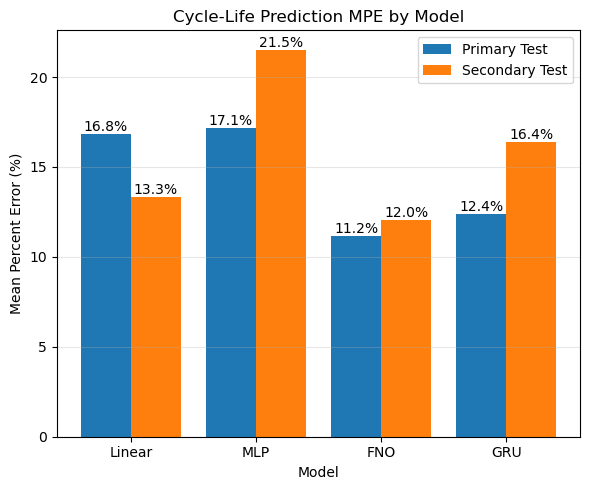

In [12]:
# MPE Bar Chart
models = ["Linear", "MLP", "FNO", "GRU"]
splits = ["Primary", "Secondary"]

x = np.arange(len(models))
bar_width = 0.4

primary_mpe = [results[(results["model"] == model) & (results["split"] == "Primary")]["mpe"].values[0] for model in models]
secondary_mpe = [results[(results["model"] == model) & (results["split"] == "Secondary")]["mpe"].values[0] for model in models]

plt.figure(figsize=(6, 5))

plt.bar(x - bar_width / 2, primary_mpe, width=bar_width, label="Primary Test")
plt.bar(x + bar_width / 2, secondary_mpe, width=bar_width, label="Secondary Test")

plt.xticks(x, models)
plt.ylabel("Mean Percent Error (%)")
plt.xlabel("Model")
plt.title("Cycle-Life Prediction MPE by Model")
plt.legend()
plt.grid(axis="y", alpha=0.3)

# Add value labels
for i, value in enumerate(primary_mpe):
    plt.text(x[i] - bar_width / 2, value, f"{value:.1f}%", ha="center", va="bottom")

for i, value in enumerate(secondary_mpe):
    plt.text(x[i] + bar_width / 2, value, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

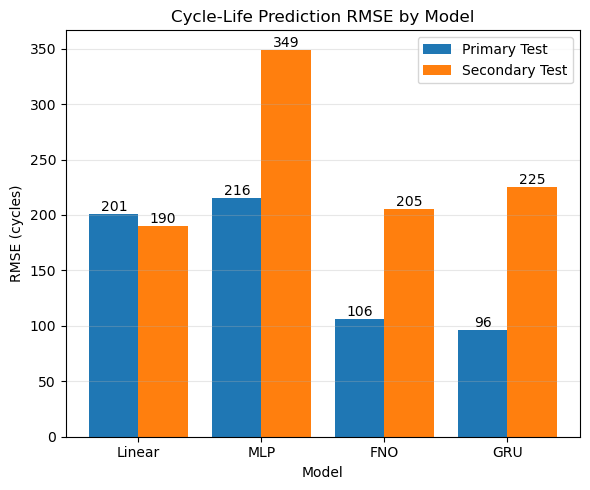

In [11]:
# RMSE Bar Chart
models = ["Linear", "MLP", "FNO", "GRU"]
splits = ["Primary", "Secondary"]

x = np.arange(len(models))
bar_width = 0.4

primary_rmse = [results[(results["model"] == model) & (results["split"] == "Primary")]["rmse"].values[0] for model in models]
secondary_rmse = [results[(results["model"] == model) & (results["split"] == "Secondary")]["rmse"].values[0] for model in models]

plt.figure(figsize=(6, 5))

plt.bar(x - bar_width / 2, primary_rmse, width=bar_width, label="Primary Test")
plt.bar(x + bar_width / 2, secondary_rmse, width=bar_width, label="Secondary Test")

plt.xticks(x, models)
plt.ylabel("RMSE (cycles)")
plt.xlabel("Model")
plt.title("Cycle-Life Prediction RMSE by Model")
plt.legend()
plt.grid(axis="y", alpha=0.3)

# Add value labels
for i, value in enumerate(primary_rmse):
    plt.text(x[i] - bar_width / 2, value, f"{value:.0f}", ha="center", va="bottom")

for i, value in enumerate(secondary_rmse):
    plt.text(x[i] + bar_width / 2, value, f"{value:.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()